# Homework part I

The first problem set contains basic tasks in PyTorch.

__Note:__ Instead of doing this part of homework, you can prove your skills otherwise:
* A commit to PyTorch or PyTorch-based repos will do;
* Fully implemented seminar assignment in tensorflow or theano will do;
* Your own project in PyTorch that is developed to a state in which a normal human can understand and appreciate what it does.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import torch, torch.nn as nn
import torch.nn.functional as F
print(torch.__version__)

2.8.0


### Task I - tensormancy

![img](https://media.giphy.com/media/3o751UMCYtSrRAFRFC/giphy.gif)

When dealing with more complex stuff like neural network, it's best if you use tensors the way samurai uses his sword. 


__1.1 The Cannabola__
[(_disclaimer_)](https://gist.githubusercontent.com/justheuristic/e2c1fa28ca02670cabc42cacf3902796/raw/fd3d935cef63a01b85ed2790b5c11c370245cbd7/stddisclaimer.h)

Let's write another function, this time in polar coordinates:
$$\rho(\theta) = (1 + 0.9 \cdot cos (8 \cdot \theta) ) \cdot (1 + 0.1 \cdot cos(24 \cdot \theta)) \cdot (0.9 + 0.05 \cdot cos(200 \cdot \theta)) \cdot (1 + sin(\theta))$$


Then convert it into cartesian coordinates ([howto](http://www.mathsisfun.com/polar-cartesian-coordinates.html)) and plot the results.

Use torch tensors only: no lists, loops, numpy arrays, etc.

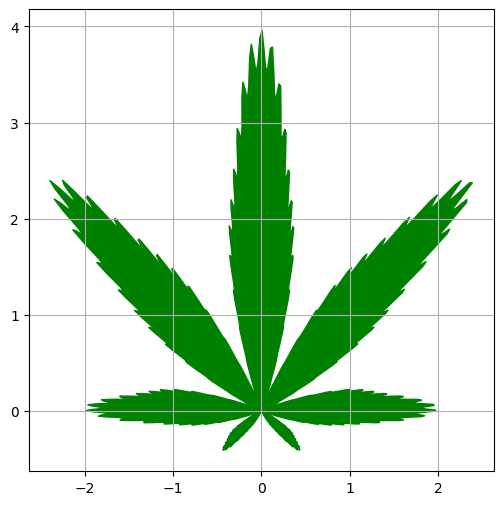

In [10]:
theta = torch.linspace(-np.pi, np.pi, steps=1000)

# compute rho(theta) as per formula above
rho = (1 + 0.9*torch.cos(8*theta)) \
    * (1 + 0.1*torch.cos(24*theta)) \
    * (0.9 + 0.05*torch.cos(200*theta)) \
    * (1 + torch.sin(theta))

# Now convert polar (rho, theta) pairs into cartesian (x,y) to plot them.
x = rho * torch.cos(theta)
y = rho * torch.sin(theta)


plt.figure(figsize=[6, 6])
plt.fill(x.numpy(), y.numpy(), color='green')
plt.grid()

### Task II: The Game of Life

Now it's time for you to make something more challenging. We'll implement Conway's [Game of Life](http://web.stanford.edu/~cdebs/GameOfLife/) in _pure PyTorch_.

While this is still a toy task, implementing game of life this way has one cool benefit: __you'll be able to run it on GPU!__ Indeed, what could be a better use of your GPU than simulating Game of Life on 1M/1M grids?

![img](https://upload.wikimedia.org/wikipedia/commons/e/e5/Gospers_glider_gun.gif)

If you've skipped the URL above out of sloth, here's the Game of Life:
* You have a 2D grid of cells, where each cell is "alive"(1) or "dead"(0)
* Any living cell that has 2 or 3 neighbors survives, else it dies [0,1 or 4+ neighbors]
* Any cell with exactly 3 neighbors becomes alive (if it was dead)

For this task, you are given a reference NumPy implementation that you must convert to PyTorch.
_[NumPy code inspired by: https://github.com/rougier/numpy-100]_


__Note:__ You can find convolution in `torch.nn.functional.conv2d(Z,filters)`. Note that it has a different input format.

__Note 2:__ From the mathematical standpoint, PyTorch convolution is actually cross-correlation. Those two are very similar operations. More info: [video tutorial](https://www.youtube.com/watch?v=C3EEy8adxvc), [scipy functions review](http://programmerz.ru/questions/26903/2d-convolution-in-python-similar-to-matlabs-conv2-question), [stack overflow source](https://stackoverflow.com/questions/31139977/comparing-matlabs-conv2-with-scipys-convolve2d).

In [13]:
from scipy.signal import correlate2d

def np_update(Z):
    # Count neighbours with convolution
    filters = np.array([[1, 1, 1],
                        [1, 0, 1],
                        [1, 1, 1]])

    N = correlate2d(Z, filters, mode='same')

    # Apply rules
    birth = (N == 3) & (Z == 0)
    survive = ((N == 2) | (N == 3)) & (Z == 1)

    Z[:] = birth | survive
    return Z

In [15]:
def torch_update(Z):
    """
    Implement an update function that does to Z exactly the same as np_update.
    :param Z: torch.FloatTensor of shape [height,width] containing 0s(dead) an 1s(alive)
    :returns: torch.FloatTensor Z after updates.
    
    You can opt to create new tensor or change Z inplace.
    """
    
    kernel = torch.tensor([[1, 1, 1],
                           [1, 0, 1],
                           [1, 1, 1]], dtype=Z.dtype, device=Z.device).view(1, 1, 3, 3)
    N = F.conv2d(Z.unsqueeze(0).unsqueeze(0), kernel, padding=1)[0, 0]

    birth   = (N == 3) & (Z == 0)
    survive = ((N == 2) | (N == 3)) & (Z == 1)

    Z = (birth | survive).to(Z.dtype)
    
    return Z


In [17]:
# initial frame
Z_numpy = np.random.choice([0, 1], p=(0.5, 0.5), size=(100, 100))
Z = torch.from_numpy(Z_numpy).type(torch.FloatTensor)

# your debug polygon :)
Z_new = torch_update(Z.clone())

# tests
Z_reference = np_update(Z_numpy.copy())
assert np.all(Z_new.numpy() == Z_reference), \
    "your PyTorch implementation doesn't match np_update. Look into Z and np_update(ZZ) to investigate."
print("Well done!")

Well done!


/var/folders/b2/cyy0_v0n2p321tcwcfcl9rfh0000gn/T/ipykernel_69403/3632238732.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


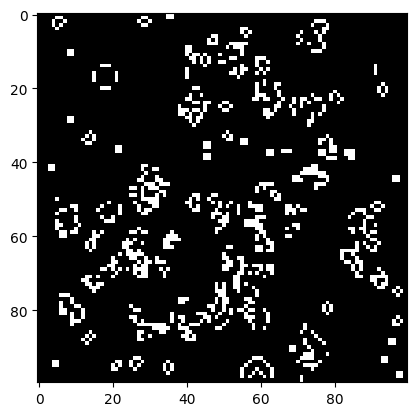

In [25]:
%matplotlib notebook
plt.ion()

# initialize game field
Z = np.random.choice([0, 1], size=(100, 100))
Z = torch.from_numpy(Z).type(torch.FloatTensor)

fig = plt.figure()
ax = fig.add_subplot(111)
fig.show()

for _ in range(100):
    # update
    Z = torch_update(Z)

    # re-draw image
    ax.clear()
    ax.imshow(Z.numpy(), cmap='gray')
    fig.canvas.draw()

/var/folders/b2/cyy0_v0n2p321tcwcfcl9rfh0000gn/T/ipykernel_69403/2483044044.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


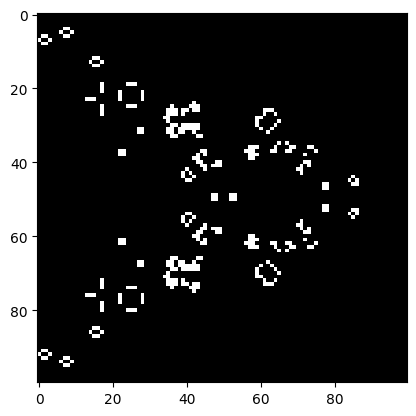

In [27]:
# Some fun setups for your amusement

# parallel stripes
Z = np.arange(100) % 2 + np.zeros([100, 100])
# with a small imperfection
Z[48:52, 50] = 1

Z = torch.from_numpy(Z).type(torch.FloatTensor)

fig = plt.figure()
ax = fig.add_subplot(111)
fig.show()

for _ in range(100):
    Z = torch_update(Z)
    ax.clear()
    ax.imshow(Z.numpy(), cmap='gray')
    fig.canvas.draw()

More fun with Game of Life: [video](https://www.youtube.com/watch?v=C2vgICfQawE) and/or [Jupyter Notebook](https://nbviewer.jupyter.org/url/norvig.com/ipython/Life.ipynb)

### Task III: Going deeper
<img src="https://www.meme-arsenal.com/memes/00ad90d844e491aaeb6892515c716710.jpg" width=360>

Your third trial is to build your first neural network [almost] from scratch and pure PyTorch.

This time you will solve yet another digit recognition problem, but at a greater scale

* 10 different letters
* 20k samples

We want you to build a network that reaches at least 80% accuracy and has at least 2 linear layers in it. Naturally, it should be nonlinear to beat logistic regression.


With 10 classes you will need to use __Softmax__ at the top instead of sigmoid and train using __categorical crossentropy__ .  Write your own loss or use `torch.nn.functional.nll_loss`. Just make sure you understand what it accepts as input.

Note that you are not required to build 152-layer monsters here. A 2-layer (one hidden, one output) neural network should already give you an edge over logistic regression.


__[bonus kudos]__
If you've already beaten logistic regression with a two-layer net, but enthusiasm still ain't gone, you can try improving the test accuracy even further! It should be possible to reach 90% without convnets.

__SPOILERS!__
At the end of the notebook you will find a few tips and frequent errors.
If you feel confident enough, just start coding right away and get there ~~if~~ once you need to untangle yourself.

In [29]:
!wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_DL/fall21/week02_autodiff/notmnist.py

In [3]:
from notmnist import load_notmnist
X_train, y_train, X_test, y_test = load_notmnist(letters='ABCDEFGHIJ')
X_train, X_test = X_train.reshape([-1, 784]), X_test.reshape([-1, 784])

Parsing...
found broken img: ./notMNIST_small/A/RGVtb2NyYXRpY2FCb2xkT2xkc3R5bGUgQm9sZC50dGY=.png [it's ok if <10 images are broken]
found broken img: ./notMNIST_small/F/Q3Jvc3NvdmVyIEJvbGRPYmxpcXVlLnR0Zg==.png [it's ok if <10 images are broken]
Done


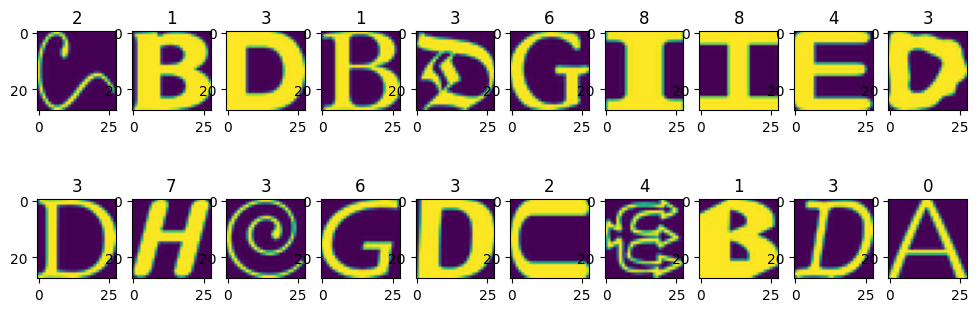

In [37]:
%matplotlib inline
plt.figure(figsize=[12, 4])
for i in range(20):
    plt.subplot(2, 10, i+1)
    plt.imshow(X_train[i].reshape([28, 28]))
    plt.title(str(y_train[i]))

In [ ]:
#< a whole lot of your code > 

In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cpu


In [41]:
X_train_t = torch.from_numpy(X_train).float() / 255.0  # [N, 784]
X_test_t  = torch.from_numpy(X_test ).float() / 255.0
y_train_t = torch.from_numpy(y_train).long()
y_test_t  = torch.from_numpy(y_test ).long()

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=1024, shuffle=False, drop_last=False)

In [43]:
@torch.no_grad()
def accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        pred = logits.argmax(dim=1)
        correct += (pred == yb).sum().item()
        total += yb.numel()
    return correct / total

def train(model, loader, epochs, lr=1e-2, weight_decay=0.0, optimizer='sgd'):
    model.to(device)
    if optimizer == 'adam':
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(set_to_none=True)
            logits = model(xb)                
            loss = F.cross_entropy(logits, yb)
            loss.backward()
            opt.step()
            running += loss.item() * xb.size(0)

        tr_loss = running / len(loader.dataset)
        print(f"Epoch {epoch:02d} | train loss: {tr_loss:.4f}")

In [45]:
class LogisticRegression(nn.Module):
    def __init__(self, in_dim=784, n_classes=10):
        super().__init__()
        self.linear = nn.Linear(in_dim, n_classes)
    def forward(self, x):
        return self.linear(x) 

In [47]:
logreg = LogisticRegression().to(device)
print("\nTraining logistic regression...")
train(logreg, train_loader, epochs=12, lr=0.2, weight_decay=1e-4, optimizer='sgd')
logreg_train_acc = accuracy(logreg, train_loader)
logreg_test_acc  = accuracy(logreg, test_loader)
print(f"LogReg accuracy: train={logreg_train_acc*100:.2f}% | test={logreg_test_acc*100:.2f}%")


Training logistic regression...
Epoch 01 | train loss: 2.2937
Epoch 02 | train loss: 2.2672
Epoch 03 | train loss: 2.2405
Epoch 04 | train loss: 2.2155
Epoch 05 | train loss: 2.1891
Epoch 06 | train loss: 2.1646
Epoch 07 | train loss: 2.1412
Epoch 08 | train loss: 2.1181
Epoch 09 | train loss: 2.0958
Epoch 10 | train loss: 2.0745
Epoch 11 | train loss: 2.0540
Epoch 12 | train loss: 2.0335
LogReg accuracy: train=67.69% | test=65.97%


In [49]:
class MLP(nn.Module):
    def __init__(self, in_dim=784, hidden=256, n_classes=10, p_drop=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(inplace=True),       
            nn.Dropout(p_drop),
            nn.Linear(hidden, n_classes)
        )
    def forward(self, x):
        return self.net(x)

In [51]:
mlp = MLP().to(device)
print("\nTraining 1-hidden-layer MLP...")
train(mlp, train_loader, epochs=20, lr=1e-3, weight_decay=1e-4, optimizer='adam')
mlp_train_acc = accuracy(mlp, train_loader)
mlp_test_acc  = accuracy(mlp, test_loader)
print(f"MLP accuracy:    train={mlp_train_acc*100:.2f}% | test={mlp_test_acc*100:.2f}%")


Training 1-hidden-layer MLP...
Epoch 01 | train loss: 2.2180
Epoch 02 | train loss: 1.7554
Epoch 03 | train loss: 1.2171
Epoch 04 | train loss: 0.9289
Epoch 05 | train loss: 0.7847
Epoch 06 | train loss: 0.6979
Epoch 07 | train loss: 0.6433
Epoch 08 | train loss: 0.6074
Epoch 09 | train loss: 0.5808
Epoch 10 | train loss: 0.5602
Epoch 11 | train loss: 0.5472
Epoch 12 | train loss: 0.5325
Epoch 13 | train loss: 0.5248
Epoch 14 | train loss: 0.5130
Epoch 15 | train loss: 0.5053
Epoch 16 | train loss: 0.4997
Epoch 17 | train loss: 0.4906
Epoch 18 | train loss: 0.4863
Epoch 19 | train loss: 0.4828
Epoch 20 | train loss: 0.4759
MLP accuracy:    train=88.56% | test=87.55%


# SPOILERS!

Recommended pipeline:

* Adapt logistic regression from seminar assignment to classify one letter against others (e.g. A vs the rest)
* Generalize it to multiclass logistic regression.
  - Either try to remember lecture 0 or google it.
  - Instead of weight vector you'll have to use matrix (feature_id x class_id)
  - Softmax (exp over sum of exps) can be implemented manually or as `nn.Softmax` (layer) or `F.softmax` (function)
  - Probably better to use STOCHASTIC gradient descent (minibatch) for greater speed
    - You can also try momentum/rmsprop/adawhatever
    - in which case the dataset should probably be shuffled (or use random subsamples on each iteration)
* Add a hidden layer. Now your logistic regression uses hidden neurons instead of inputs.
  - Hidden layer uses the same math as output layer (ex-logistic regression), but uses some nonlinearity (e.g. sigmoid) instead of softmax
  - You need to train both layers, not just the output layer :)
  - 50 hidden neurons and a sigmoid nonlinearity will do for a start. Many ways to improve.
  - In ideal case this totals to 2 `torch.matmul`'s, 1 softmax and 1 ReLU/sigmoid
  - __Make sure this neural network works better than logistic regression!__

* Now's the time to try improving the network. Consider layers (size, neuron count), nonlinearities, optimization methods, initialization — whatever you want, but please avoid convolutions for now.

* If anything seems wrong, try going through one step of training and printing everything you compute.
* If you see NaNs midway through optimization, you can estimate $\log P(y \mid x)$ as `F.log_softmax(layer_before_softmax)`.